In [ ]:
# the analysis use simulated data since I dont know where to get the raw data
# The setup is 12 donors, 3 skin pieces per donor and 5 Raman spectra per piece. Each piece has a hidden lipid order, where ordered lipids give a tighter barrier and therefore lower flux. 
# One IVPT flux value is attached to each piece.

In [1]:
# packages

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import sparse
from scipy.sparse.linalg import spsolve
from scipy.signal import savgol_filter, medfilt
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import KFold, GroupKFold, cross_val_predict
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [6]:
# functions helper

# save output
def save(name):
    plt.tight_layout(); plt.savefig(OUT / f"{name}.png", dpi=130); plt.close()

# gaussian dist
def gauss(x, centre, width, height):
    return height * np.exp(-0.5 * ((x - centre) / width) ** 2)

# define the base skin raman spectra
def clean_skin_spectrum(order):
    # Noise-free spectrum of stratum corneum for a given lipid order (0-1)
    s = np.zeros_like(wn)
    # --- lipid skeleton region ---
    s += gauss(wn, 1062, 6, 0.30 + 0.45 * order)     # C-C trans stretch
    s += gauss(wn, 1130, 6, 0.30 + 0.45 * order)     # C-C trans stretch
    s += gauss(wn, 1080, 14, 0.15 + 0.50 * (1 - order))  # C-C gauche (disorder)
    s += gauss(wn, 1296, 8, 0.55)                    # CH2 twist
    s += gauss(wn, 1440, 12, 0.85)                   # CH2 bend
    # --- protein bands (keratin) ---
    s += gauss(wn, 1003, 4, 0.20)                    # phenylalanine ring
    s += gauss(wn, 1655, 14, 0.90)                   # amide I
    # --- CH stretching region ---
    nu_s = 2854.0 - 4.0 * order                      # order -> band shifts DOWN
    s += gauss(wn, nu_s, 9, 1.00)                    # nu_s(CH2) ~2850
    s += gauss(wn, 2880, 10, 0.55 + 0.80 * order)    # nu_as(CH2) ~2880
    s += gauss(wn, 2935, 14, 0.90)                   # CH3 / protein
    return s

In [ ]:
# 1 -- raw data generation set up

# randomize
RNG = np.random.default_rng(42) # fixed seed >>> reproducible results
OUT = Path("demo_figures"); OUT.mkdir(exist_ok=True)

# setup
wn = np.arange(600, 3100, 2.0) # wavenumber axis in cm-1
N_DONORS, PIECES, SPECTRA = 12, 3, 5
rows, spectra = [], []
# donor "signature": a few random small peaks, unique to each donor
sig_pos = RNG.uniform(700, 1700, 6)

In [ ]:
# simulate the data
for d in range(N_DONORS):
    donor_O = np.clip(RNG.normal(0.60, 0.12), 0.2, 0.9)   # donor mean order
    sig_coef = RNG.normal(0, 1, 6)                         # donor signature
    donor_effect = 0.6 * sig_coef[:3].sum() / np.sqrt(3)   # tied to signature
    signature = sum(gauss(wn, p, 10, 0.06 * c) for p, c in zip(sig_pos, sig_coef))
    for p in range(PIECES):
        piece_O = np.clip(donor_O + RNG.normal(0, 0.12), 0.05, 0.95)
        flux = 2.0 + 3.0 * (1 - piece_O) + donor_effect + RNG.normal(0, 0.35)
        for k in range(SPECTRA):
            O = np.clip(piece_O + RNG.normal(0, 0.03), 0, 1)
            clean = clean_skin_spectrum(O) + signature
            # fluorescence baseline: slope + curve + broad hump (much bigger than peaks!)
            x = (wn - wn.min()) / (wn.max() - wn.min())
            base = (RNG.uniform(1, 3) + RNG.uniform(-1, 1) * x
                    + RNG.uniform(-1, 1) * x ** 2
                    + gauss(x, RNG.uniform(0.2, 0.6), 0.25, RNG.uniform(0.5, 1.5)))
            noise = RNG.normal(0, 0.02, wn.size)
            spec = RNG.uniform(0.7, 1.3) * clean + base + noise  # random intensity scale
            if RNG.random() < 0.15:                              # cosmic-ray spikes
                for _ in range(RNG.integers(1, 3)):
                    spec[RNG.integers(5, wn.size - 5)] += RNG.uniform(2, 5)
            spectra.append(spec)
            rows.append(dict(donor=f"D{d+1:02d}", piece=f"D{d+1:02d}_P{p+1}",
                             true_order=O, flux=flux))
 
meta = pd.DataFrame(rows)                  # one row per spectrum (the metadata table)
X_raw = np.array(spectra)                  # shape (180, n_wavenumbers)
print("Spectra matrix:", X_raw.shape, "| donors:", meta.donor.nunique(),
      "| pieces:", meta.piece.nunique())
print(meta.head())

Spectra matrix: (180, 1250) | donors: 12 | pieces: 36
  donor   piece  true_order      flux
0   D01  D01_P1    0.724831  2.500926
1   D01  D01_P1    0.761801  2.500926
2   D01  D01_P1    0.766876  2.500926
3   D01  D01_P1    0.736303  2.500926
4   D01  D01_P1    0.763186  2.500926


NameError: name 'handles' is not defined

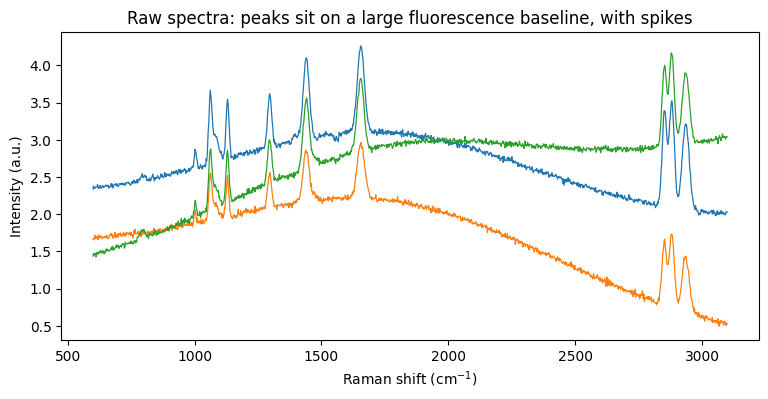

In [ ]:
# visualize the raw data
plt.figure(figsize=(9, 4))
for i in [0, 40, 100]:
    plt.plot(wn, X_raw[i], lw=0.9)
plt.xlabel("Raman shift (cm$^{-1}$)"); plt.ylabel("Intensity (a.u.)")
plt.title("Raw spectra: peaks sit on a large fluorescence baseline, with spikes")
# plt.legend(handles, labels)

# save("01_raw_spectra")